#Project Setup

In [1]:
!pip install -q ultralytics efficientnet_pytorch opencv-python requests

!wget -q https://raw.githubusercontent.com/SJones339/FoodVision/main/models/yolov8m_food_best.pt
!wget -q https://raw.githubusercontent.com/SJones339/FoodVision/main/models/efficientnet_best.pth
!wget -q https://raw.githubusercontent.com/SJones339/FoodVision/main/meal.jpg
!wget -q https://raw.githubusercontent.com/SJones339/FoodVision/main/food_classes.json


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 39.8 MB/s eta 0:00:00


In [2]:
import json
import torch
import torch.nn as nn
import numpy as np
import cv2
import requests
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from PIL import Image
from torchvision import transforms
from ultralytics import YOLO
from efficientnet_pytorch import EfficientNet

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Device: cuda


In [7]:
!wget -q https://raw.githubusercontent.com/SJones339/FoodVision/main/food_classes.json -O food_classes.json

In [9]:
!ls -l food_classes.json
!sed -n '1,20p' food_classes.json


-rw-r--r-- 1 root root 0 Dec 17 22:10 food_classes.json


#Loading DATA, YOLOv8, EfficientNET

In [10]:
# ----------------------------------------------------
# YOLO FoodSeg103 class → name mapping
# Inline on purpose (no runtime downloads)
# ----------------------------------------------------

food_names = {
    0: "background",
    1: "candy",
    2: "egg tart",
    3: "french fries",
    4: "chocolate",
    5: "biscuit",
    6: "popcorn",
    7: "pudding",
    8: "ice cream",
    9: "cheese butter",
    10: "cake",
    11: "wine",
    12: "milkshake",
    13: "coffee",
    14: "juice",
    15: "milk",
    16: "tea",
    17: "almond",
    18: "red beans",
    19: "cashew",
    20: "dried cranberries",
    21: "soy",
    22: "walnut",
    23: "peanut",
    24: "egg",
    25: "apple",
    26: "date",
    27: "apricot",
    28: "avocado",
    29: "banana",
    30: "strawberry",
    31: "cherry",
    32: "blueberry",
    33: "raspberry",
    34: "mango",
    35: "olives",
    36: "peach",
    37: "lemon",
    38: "pear",
    39: "fig",
    40: "pineapple",
    41: "grape",
    42: "kiwi",
    43: "melon",
    44: "orange",
    45: "watermelon",
    46: "steak",
    47: "pork",
    48: "chicken duck",
    49: "sausage",
    50: "fried meat",
    51: "lamb",
    52: "sauce",
    53: "crab",
    54: "fish",
    55: "shellfish",
    56: "shrimp",
    57: "soup",
    58: "bread",
    59: "corn",
    60: "hamburg",
    61: "pizza",
    62: "hanamaki baozi",
    63: "wonton dumplings",
    64: "pasta",
    65: "noodles",
    66: "rice",
    67: "pie",
    68: "tofu",
    69: "eggplant",
    70: "potato",
    71: "garlic",
    72: "cauliflower",
    73: "tomato",
    74: "kelp",
    75: "seaweed",
    76: "spring onion",
    77: "rape",
    78: "ginger",
    79: "okra",
    80: "lettuce",
    81: "pumpkin",
    82: "cucumber",
    83: "white radish",
    84: "carrot",
    85: "asparagus",
    86: "bamboo shoots",
    87: "broccoli",
    88: "celery stick",
    89: "cilantro mint",
    90: "snow peas",
    91: "cabbage",
    92: "bean sprouts",
    93: "onion",
    94: "pepper",
    95: "green beans",
    96: "French beans",
    97: "king oyster mushroom",
    98: "shiitake",
    99: "enoki mushroom",
    100: "oyster mushroom",
    101: "white button mushroom",
    102: "salad",
    103: "other ingredients"
}

print("Loaded", len(food_names), "food classes")

Loaded 104 food classes


In [11]:
yolo = YOLO("yolov8m_food_best.pt")
_ = yolo("meal.jpg", verbose=False)  # warmup


In [12]:
effnet = EfficientNet.from_name("efficientnet-b0")
effnet._fc = nn.Linear(effnet._fc.in_features, 101)

state = torch.load("efficientnet_best.pth", map_location="cpu")
effnet.load_state_dict(state, strict=False)

effnet.to(device).eval()

eff_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])


##Running YOLO once/visualziation + sanity check

In [14]:
image_path = "meal.jpg"
img_pil = Image.open(image_path).convert("RGB")
img_np = np.array(img_pil)

res = yolo(image_path, verbose=False)[0]

boxes = res.boxes.xyxy.cpu().numpy()
classes = res.boxes.cls.cpu().numpy().astype(int)
confs = res.boxes.conf.cpu().numpy()
masks_low = res.masks.data  # (N, h, w)

H, W = img_np.shape[:2]

# Upsample masks to full resolution
masks = torch.nn.functional.interpolate(
    masks_low.unsqueeze(1).float(),
    size=(H, W),
    mode="bilinear",
    align_corners=False
).squeeze(1).cpu().numpy() > 0.5


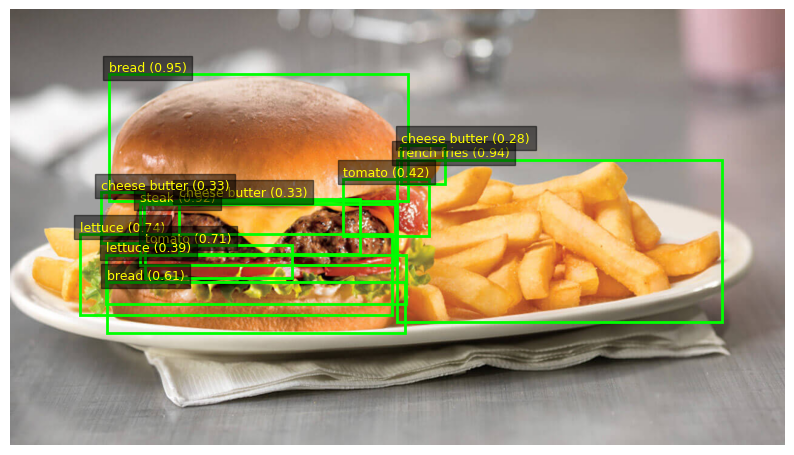

In [15]:
fig, ax = plt.subplots(1, figsize=(10,8))
ax.imshow(img_np)

for (x1,y1,x2,y2), cls, conf in zip(boxes, classes, confs):
    x1,y1,x2,y2 = map(int,[x1,y1,x2,y2])
    ax.add_patch(patches.Rectangle(
        (x1,y1), x2-x1, y2-y1,
        edgecolor="lime", facecolor="none", linewidth=2
    ))
    ax.text(x1,y1-5,
            f"{food_names[cls]} ({conf:.2f})",
            color="yellow", fontsize=9,
            bbox=dict(facecolor="black", alpha=0.5))

ax.axis("off")
plt.show()


##Running Midas Depth Once

In [16]:
midas = torch.hub.load("intel-isl/MiDaS", "DPT_Large").to(device)
midas.eval()
midas_tf = torch.hub.load("intel-isl/MiDaS", "transforms").dpt_transform

img_bgr = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

with torch.no_grad():
    depth = midas(midas_tf(img_rgb).to(device)).squeeze().cpu().numpy()

depth = cv2.resize(depth, (W, H))


/usr/local/lib/python3.12/dist-packages/torch/hub.py:335: UserWarning: You are about to download and run code from an untrusted repository. In a future release, this won't be allowed. To add the repository to your trusted list, change the command to {calling_fn}(..., trust_repo=False) and a command prompt will appear asking for an explicit confirmation of trust, or load(..., trust_repo=True), which will assume that the prompt is to be answered with 'yes'. You can also use load(..., trust_repo='check') which will only prompt for confirmation if the repo is not already trusted. This will eventually be the default behaviour
  warnings.warn(


Downloading: "https://github.com/intel-isl/MiDaS/zipball/master" to /root/.cache/torch/hub/master.zip
Downloading: "https://github.com/isl-org/MiDaS/releases/download/v3/dpt_large_384.pt" to /root/.cache/torch/hub/checkpoints/dpt_large_384.pt


100%|██████████| 1.28G/1.28G [00:36<00:00, 37.6MB/s]
Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master


#Volume Estimation function

In [27]:
def estimate_volume_ml(depth, mask, plate_mm=250, plate_px=600):
    ys, xs = np.where(mask)
    if len(xs) < 50:
        return 0.0

    d = depth[ys, xs]
    baseline = np.percentile(d, 95)
    height = np.clip(baseline - d, 0, None)

    mm_per_px = plate_mm / plate_px
    volume_mm3 = np.sum(height) * (mm_per_px ** 2)
    return volume_mm3 / 1000  # ml


#USDA Nutrition Lookup

In [38]:
def get_usda_macros(food_name, volume_ml):
    """
    Uses USDA FoodData Central.
    If depth-based volume is unreliable, falls back to USDA serving size.
    """

    api_key = os.environ["USDA_API_KEY"]

    # -------------------------
    # 1. Query USDA (POST)
    # -------------------------
    r = requests.post(
        "https://api.nal.usda.gov/fdc/v1/foods/search",
        params={"api_key": api_key},
        json={"query": food_name, "pageSize": 5},
        timeout=10
    )
    r.raise_for_status()
    data = r.json()

    foods = data.get("foods", [])
    if not foods:
        return None

    food = foods[0]

    # -------------------------
    # 2. Depth-based grams
    # -------------------------
    grams_depth = volume_ml * 1.0  # g/ml fallback density

    # -------------------------
    # 3. USDA serving-size fallback
    # -------------------------
    grams_serving = None
    serving_size = food.get("servingSize")
    serving_unit = food.get("servingSizeUnit", "").lower()

    if serving_size is not None:
        if serving_unit == "g":
            grams_serving = float(serving_size)
        elif serving_unit in ["ml", "milliliter"]:
            grams_serving = float(serving_size)
        # otherwise ignore (cups, pieces, etc.)

    # -------------------------
    # 4. Choose grams estimate
    # -------------------------
    # use USDA serving if depth-based estimate is implausibly small
    if grams_serving is not None and grams_depth < 0.5 * grams_serving:
        grams = grams_serving
    else:
        grams = grams_depth


    # -------------------------
    # 5. Extract nutrients (per 100g)
    # -------------------------
    macros_100g = {}

    for n in food.get("foodNutrients", []):
        name = n.get("nutrientName", "").lower()
        unit = n.get("unitName", "").lower()
        val = n.get("value")

        if val is None:
            continue

        if "energy" in name and unit == "kcal":
            macros_100g["cal"] = val
        elif "protein" in name:
            macros_100g["protein"] = val
        elif "carbohydrate" in name:
            macros_100g["carbs"] = val
        elif "total lipid" in name or "fat" in name:
            macros_100g["fat"] = val

    if not macros_100g:
        return None

    # -------------------------
    # 6. Scale to portion
    # -------------------------
    scale = grams / 100.0
    return {k: float(v * scale) for k, v in macros_100g.items()}


#Putting Everythign Together

In [32]:
import os
# Set this in your shell instead of hardcoding secrets in the notebook:
#   export USDA_API_KEY="..."
assert os.getenv("USDA_API_KEY"), "Missing USDA_API_KEY env var"


In [37]:
total = {"cal":0,"protein":0,"carbs":0,"fat":0}

for i in range(len(boxes)):
    food = food_names[classes[i]]
    vol = estimate_volume_ml(depth, masks[i])
    macros = get_usda_macros(food, vol)

    print(f"\n{food.upper()}")
    print(f"Confidence: {confs[i]:.2f}")
    print(f"Volume (ml): {vol:.1f}")

    if macros:
        for k in total:
            total[k] += macros.get(k,0)
        clean_macros = {k: float(v) for k, v in macros.items()}
        print(clean_macros)
    else:
        print("No USDA data")

print("\n===== TOTAL MEAL =====")
print(total)



BREAD
Confidence: 0.95
Volume (ml): 22.6
{'protein': 0.8079026937484741, 'fat': 0.0, 'carbs': 7.2643351554870605, 'cal': 33.040279388427734}

FRENCH FRIES
Confidence: 0.94
Volume (ml): 41.2
{'protein': 1.9991999999999999, 'fat': 1.9991999999999999, 'carbs': 18.984, 'cal': 150.35999999999999}

STEAK
Confidence: 0.92
Volume (ml): 3.0
{'protein': 0.0, 'fat': 0.0, 'carbs': 3.334043264389038, 'cal': 16.700252532958984}

LETTUCE
Confidence: 0.74
Volume (ml): 4.3
{'protein': 0.039418090134859085, 'fat': 0.004627340938895941, 'carbs': 0.15810081362724304, 'cal': 0.8569149971008301}

TOMATO
Confidence: 0.71
Volume (ml): 1.1
{'fat': 0.0}

BREAD
Confidence: 0.61
Volume (ml): 4.0
{'protein': 0.9996, 'fat': 0.0, 'carbs': 8.988000000000001, 'cal': 40.88}

TOMATO
Confidence: 0.42
Volume (ml): 1.2
{'fat': 0.0}

LETTUCE
Confidence: 0.39
Volume (ml): 4.1
{'protein': 0.03754296526312828, 'fat': 0.004407217726111412, 'carbs': 0.15057994425296783, 'cal': 0.8161514401435852}

CHEESE BUTTER
Confidence: 0.33